# 🔶 Data Mining & Warehousing - PART 01

## 🔸PreProcessing of the Data

In [ ]:
!pip install pandas openpyxl mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 31.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_excel("/content/DHV Project Dataset...Indian_Economy_&_GDP_Growth.xlsx")

df.head()

,Year,GDP (Nominal),GDP (Real),GDP growth (annual %),Agriculture Contribution (% of GDP),Industry Contribution (% of GDP),Services Contribution (% of GDP),Inflation CPI,Unemployment Rate (%),Exports (% of GDP),...,Population Growth Rate (annual %),Oil rents (% of GDP),Government Revenues (% of GDP),Household Consumption Expenditure (% of GDP),Gross Fixed Capital Formation (% of GDP),Private Sector Credit (% of GDP),Poverty Rate (%),Energy Consumption per Capita (kWh),Current Account Balance (% of GDP),Tax revenue (% of GDP)
0,1971,35.58,67.4,1.642930,34.58,26.47,43.32,5.324841,5.3,3.667205,...,5.307963,0.087218,9.74,54.9,16.59,12.49,45.3,250,-0.5,9.06
1,1972,36.06,71.5,-0.553301,34.44,26.48,43.74,10.839600,5.3,4.027489,...,5.678821,0.078421,9.63,56.7,17.05,12.92,45.3,258,-0.4,9.25
2,1973,38.32,85.5,3.295521,34.06,25.77,44.11,17.829720,5.0,4.208763,...,5.705386,0.077427,9.58,58.4,15.91,13.09,44.4,269,-0.2,9.16
3,1974,38.47,99.5,1.185336,34.23,25.85,43.77,16.667520,5.2,4.831321,...,5.712841,0.426931,9.90,60.0,16.60,12.91,44.0,274,-1.0,8.43
4,1975,41.57,98.5,9.149912,35.26,25.19,43.52,-1.648680,4.9,5.647062,...,5.655836,0.534883,10.09,61.2,17.71,14.93,44.0,288,-1.4,8.66


In [ ]:
# STEP 2: Strip unwanted spaces from original column names
df.columns = df.columns.str.strip()

# STEP 3: Create explicit column mapping (VERY IMPORTANT)
column_mapping = {
    "Year": "Year",
    "GDP (Nominal)": "GDP_Nominal",
    "GDP (Real)": "GDP_Real",
    "GDP growth (annual %)": "GDP_Growth_Annual_Percent",
    "Agriculture Contribution (% of GDP)": "Agriculture_Contribution_Percent_GDP",
    "Industry Contribution (% of GDP)": "Industry_Contribution_Percent_GDP",
    "Services Contribution (% of GDP)": "Services_Contribution_Percent_GDP",
    "Inflation CPI": "Inflation_CPI",
    "Unemployment Rate (%)": "Unemployment_Rate_Percent",
    "Exports (% of GDP)": "Exports_Percent_GDP",
    "Imports (% of GDP)": "Imports_Percent_GDP",
    "FDI Inflows (USD)": "FDI_Inflows_USD",
    "Fiscal Deficit (% of GDP)": "Fiscal_Deficit_Percent_GDP",
    "Public Debt (% of GDP)": "Public_Debt_Percent_GDP",
    "Repo Rate (%)": "Repo_Rate_Percent",
    "Foreign Exchange Reserves (MILLION USD)": "Forex_Reserves_Million_USD",
    "Population Growth Rate (annual %)": "Population_Growth_Annual_Percent",
    "Oil rents (% of GDP)": "Oil_Rents_Percent_GDP",
    "Government Revenues (% of GDP)": "Government_Revenues_Percent_GDP",
    "Household Consumption Expenditure (% of GDP)": "Household_Consumption_Percent_GDP",
    "Gross Fixed Capital Formation (% of GDP)": "GFCF_Percent_GDP",
    "Private Sector Credit (% of GDP)": "Private_Sector_Credit_Percent_GDP",
    "Poverty Rate (%)": "Poverty_Rate_Percent",
    "Energy Consumption per Capita (kWh)": "Energy_Consumption_kWh_Per_Capita",
    "Current Account Balance (% of GDP)": "Current_Account_Balance_Percent_GDP",
    "Tax revenue (% of GDP)": "Tax_Revenue_Percent_GDP"
}

In [ ]:
df = df.rename(columns=column_mapping)

In [ ]:
print("Cleaned Columns:\n")
print(df.columns.tolist())

Cleaned Columns:

['Year', 'GDP_Nominal', 'GDP_Real', 'GDP_Growth_Annual_Percent', 'Agriculture_Contribution_Percent_GDP', 'Industry_Contribution_Percent_GDP', 'Services_Contribution_Percent_GDP', 'Inflation_CPI', 'Unemployment_Rate_Percent', 'Exports_Percent_GDP', 'Imports  (% of GDP)', 'FDI Inflows (USD) In Billion', 'Fiscal_Deficit_Percent_GDP', 'Public_Debt_Percent_GDP', 'Repo_Rate_Percent', 'Forex_Reserves_Million_USD', 'Population_Growth_Annual_Percent', 'Oil_Rents_Percent_GDP', 'Government_Revenues_Percent_GDP', 'Household_Consumption_Percent_GDP', 'GFCF_Percent_GDP', 'Private_Sector_Credit_Percent_GDP', 'Poverty_Rate_Percent', 'Energy_Consumption_kWh_Per_Capita', 'Current_Account_Balance_Percent_GDP', 'Tax_Revenue_Percent_GDP']


In [ ]:
df = df.fillna(method='ffill')  # forward fill

/tmp/ipykernel_1895/4196095504.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')  # forward fill


In [ ]:
df['Year'] = df['Year'].astype(int)

In [ ]:
df.to_csv("clean_indian_economy.csv", index=False)

## 🔸Code for MySQL Workbench

In [ ]:
import pandas as pd

df = pd.read_csv("/content/clean_indian_economy.csv")

dim_time = pd.DataFrame()
dim_time['Year'] = df['Year']

dim_time['Decade'] = (df['Year']//10)*10

dim_time['Economic_Phase'] = df['Year'].apply(
    lambda x: 'Pre-1991' if x < 1991 else 'Post-1991'
)

dim_time.to_csv("dim_time.csv", index=False)

print("dim_time.csv created")

dim_time.csv created


In [ ]:
fact = df[[
    'Year',
    'GDP_Nominal',
    'GDP_Real',
    'GDP_Growth_Annual_Percent',
    'Inflation_CPI',
    'Unemployment_Rate_Percent',
    'Exports_Percent_GDP',
    'Imports  (% of GDP)',
    'FDI Inflows (USD) In Billion',
    'Fiscal_Deficit_Percent_GDP',
    'Public_Debt_Percent_GDP',
    'Current_Account_Balance_Percent_GDP'
]]

fact.to_csv("fact_economy.csv", index=False)

print("fact_economy.csv created")

fact_economy.csv created


## 🔸Data Mining and Visualisation

### ♦ Economic Clusters (K-Means + PCA)

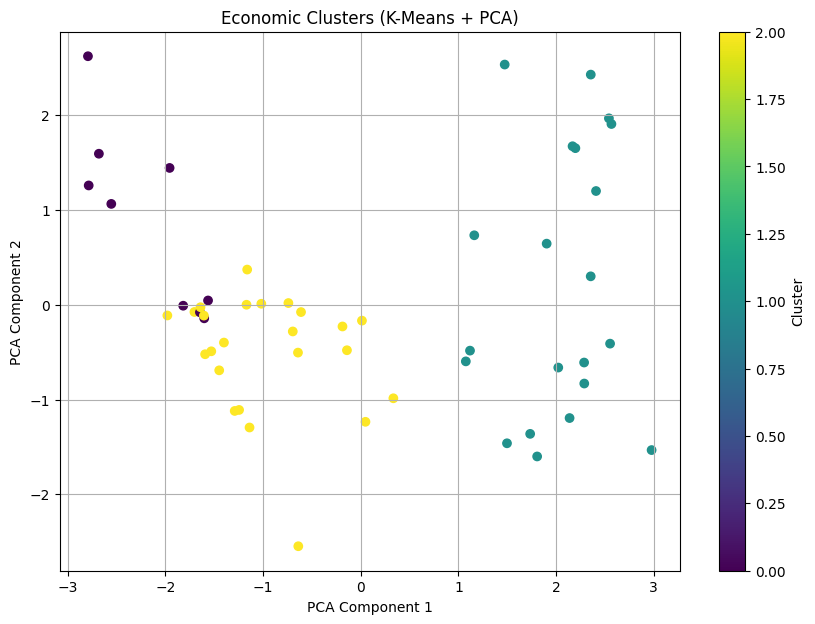

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis')
plt.title("Economic Clusters (K-Means + PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

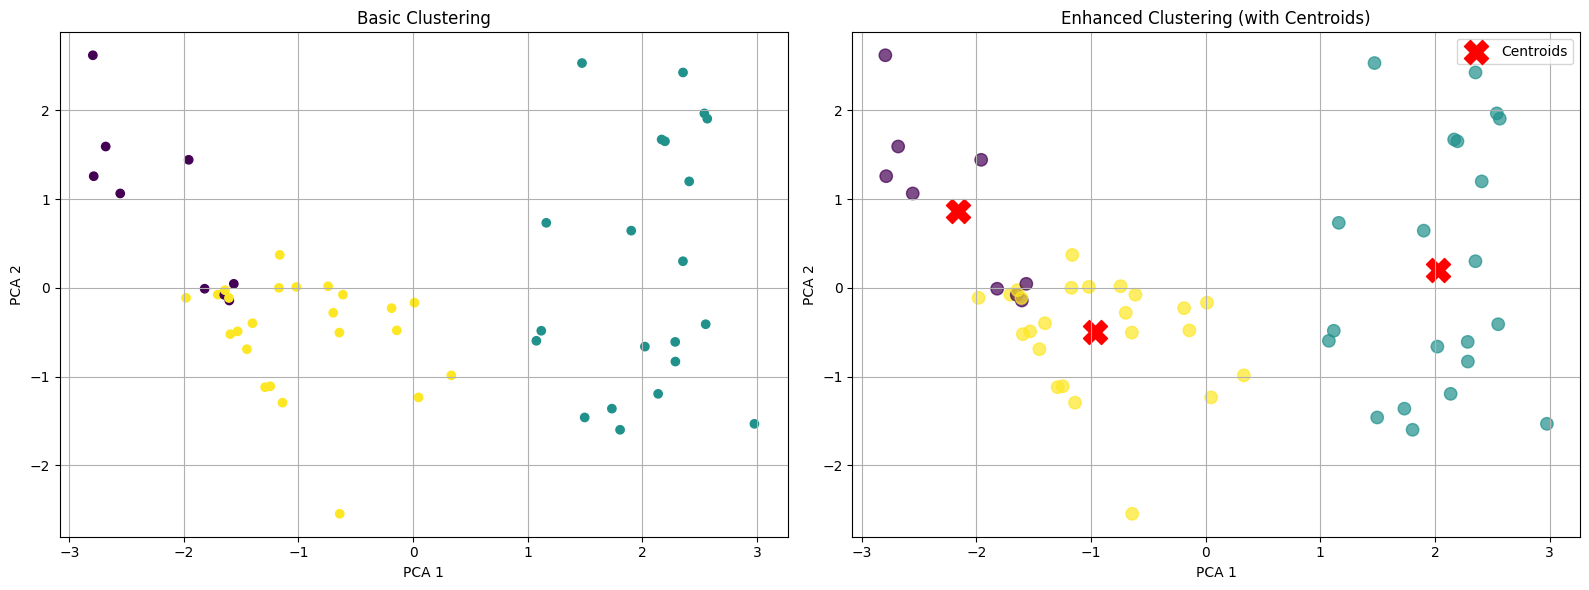

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

# ===============================
# CREATE DATAFRAME FOR PLOTLY
# ===============================
plot_df = pd.DataFrame({
    "PCA1": pca_data[:, 0],
    "PCA2": pca_data[:, 1],
    "Cluster": clusters,
    "Year": df.loc[data.index, "Year"]
})

# ===============================
# CREATE SUBPLOTS (MATPLOTLIB)
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------- Plot 1 ---------
axes[0].scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters,
    cmap='viridis'
)
axes[0].set_title("Basic Clustering")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].grid(True)

# --------- Plot 2 ---------
scatter = axes[1].scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=clusters,
    cmap='viridis',
    s=80,
    alpha=0.7
)

# Cluster centers
centers = kmeans.cluster_centers_
centers_pca = pca.transform(centers)

axes[1].scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='red',
    s=300,
    marker='X',
    label='Centroids'
)

axes[1].set_title("Enhanced Clustering (with Centroids)")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px
import pandas as pd

# Create dataframe for plotting
plot_df = pd.DataFrame({
    "PCA1": pca_data[:, 0],
    "PCA2": pca_data[:, 1],
    "Cluster": clusters,
    "Year": df.loc[data.index, "Year"]
})

fig = px.scatter(
    plot_df,
    x="PCA1",
    y="PCA2",
    color="Cluster",
    hover_data=["Year"],
    title="Interactive Economic Clusters (K-Means + PCA)"
)

fig.update_traces(marker=dict(size=10))
fig.show()

### ♦ GDP Growth vs Inflation

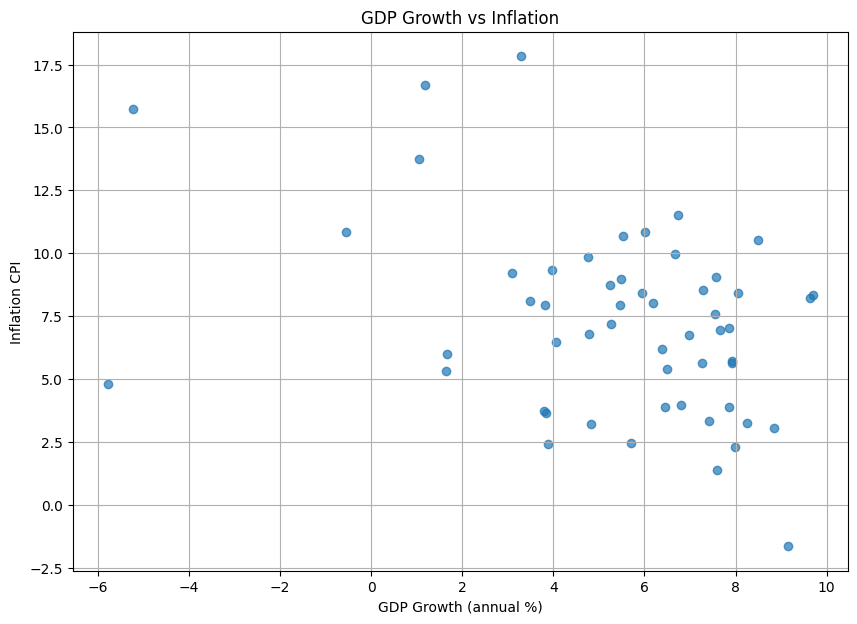

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(df['GDP growth (annual %)'], df['Inflation CPI'], alpha=0.7)
plt.xlabel("GDP Growth (annual %)")
plt.ylabel("Inflation CPI")
plt.title("GDP Growth vs Inflation")
plt.grid(True)
plt.show()

### ♦ Sector Contribution Over Time

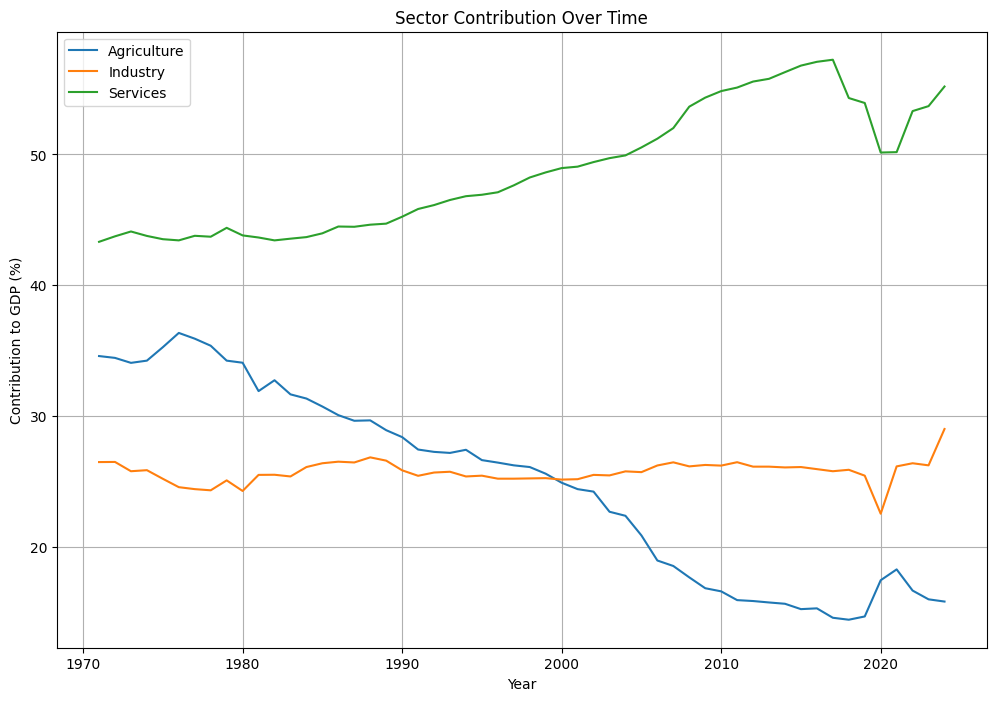

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(df['Year'], df['Agriculture Contribution (% of GDP)'], label='Agriculture')
plt.plot(df['Year'], df['Industry Contribution (% of GDP)'], label='Industry')
plt.plot(df['Year'], df['Services Contribution (% of GDP)'], label='Services')
plt.xlabel("Year")
plt.ylabel("Contribution to GDP (%)")
plt.title("Sector Contribution Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import plotly.express as px

# Convert to long format
sector_df = df[['Year',
                'Agriculture Contribution (% of GDP)',
                'Industry Contribution (% of GDP)',
                'Services Contribution (% of GDP)']]

sector_df = sector_df.melt(id_vars='Year',
                           var_name='Sector',
                           value_name='Contribution')

fig = px.area(
    sector_df,
    x="Year",
    y="Contribution",
    color="Sector",
    title="Interactive Sector Contribution Over Time"
)

fig.update_layout(width=1000, height=500)
fig.show()

### ♦ FDI vs GDP Growth

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x='FDI Inflows (USD) In Billion',
    y='GDP growth (annual %)',
    size=df['Inflation CPI'].abs(),  # Use absolute value for size
    color='Year',
    hover_data=['Year'],
    title="FDI vs GDP Growth (Interactive Analysis)"
)

fig.update_layout(width=1000, height=500)
fig.show()

In [ ]:
import plotly.express as px

# Convert to long format
macro_df = df[['Year',
               'GDP growth (annual %)',
               'Inflation CPI',
               'Unemployment Rate (%)']]

macro_df = macro_df.melt(id_vars='Year',
                         var_name='Indicator',
                         value_name='Value')

fig = px.line(
    macro_df,
    x="Year",
    y="Value",
    color="Indicator",
    markers=True,
    title="Interactive Macroeconomic Indicators Over Time"
)

fig.update_layout(width=1000, height=500)
fig.show()

# 🔶 Data Mining & Warehousing - PART 02: Random Forest

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/clean_indian_economy.csv")

# Fix oil column
df['Oil_Rents_Percent_GDP'] = pd.to_numeric(df['Oil_Rents_Percent_GDP'], errors='coerce')

In [ ]:
# Lag features
df['GDP_Lag1'] = df['GDP_Growth_Annual_Percent'].shift(1)
df['Inflation_Lag1'] = df['Inflation_CPI'].shift(1)

# Growth features
df['FDI_Growth'] = df['FDI Inflows (USD) In Billion'].pct_change()

# Drop NA after lagging
df = df.dropna()

In [ ]:
X = df.drop(['GDP_Growth_Annual_Percent', 'Year'], axis=1)
y = df['GDP_Growth_Annual_Percent']

In [ ]:
train_size = int(len(df) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.284286189809752
RMSE: 3.810041943491535
R2 Score: 0.0532332971078191


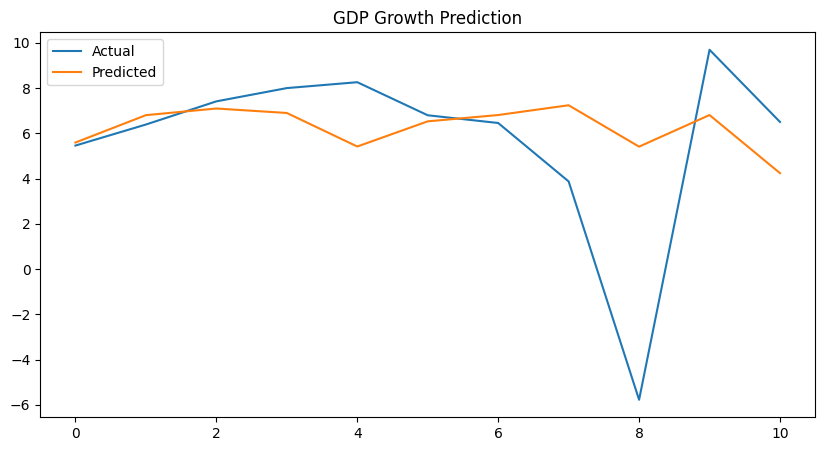

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("GDP Growth Prediction")
plt.show()

In [ ]:
important_features = [
    'Inflation_CPI',
    'Unemployment_Rate',
    'Repo_Rate',
    'FDI Inflows (USD) In Billion',
    'Gross Fixed Capital Formation',
    'Exports (% of GDP)',
    'Imports (% of GDP)',
    'Current Account Balance (% of GDP)',
    'Oil_Rents_Percent_GDP',
    'GDP_Lag1'
]

In [ ]:
df['GDP_Lag2'] = df['GDP_Growth_Annual_Percent'].shift(2)
df['Inflation_Lag2'] = df['Inflation_CPI'].shift(2)

In [ ]:
importances = model.feature_importances_

# 🔶 Data Mining & Warehousing - PART 03: UPGRADED MODEL with (XGBoost + Feature Selection)

In [ ]:
pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/clean_indian_economy.csv")

df['Oil_Rents_Percent_GDP'] = pd.to_numeric(df['Oil_Rents_Percent_GDP'], errors='coerce')

In [ ]:
# Lag features
df['GDP_Lag1'] = df['GDP_Growth_Annual_Percent'].shift(1)
df['GDP_Lag2'] = df['GDP_Growth_Annual_Percent'].shift(2)

df['Inflation_Lag1'] = df['Inflation_CPI'].shift(1)
df['Inflation_Lag2'] = df['Inflation_CPI'].shift(2)

# Growth feature
df['FDI_Growth'] = df['FDI Inflows (USD) In Billion'].pct_change()

# Drop NA
df = df.dropna()

In [ ]:
features = [
    'Inflation_CPI',
    'Unemployment_Rate_Percent',
    'Repo_Rate_Percent',
    'FDI Inflows (USD) In Billion', # Corrected to use the actual column name
    'FDI_Growth',
    'GFCF_Percent_GDP',
    'Exports_Percent_GDP',
    'Imports  (% of GDP)', # Corrected to use the actual column name
    'Current_Account_Balance_Percent_GDP',
    'Oil_Rents_Percent_GDP',
    'GDP_Lag1',
    'GDP_Lag2'
]

X = df[features]
y = df['GDP_Growth_Annual_Percent']

In [ ]:
print(df.columns.tolist())

['Year', 'GDP_Nominal', 'GDP_Real', 'GDP_Growth_Annual_Percent', 'Agriculture_Contribution_Percent_GDP', 'Industry_Contribution_Percent_GDP', 'Services_Contribution_Percent_GDP', 'Inflation_CPI', 'Unemployment_Rate_Percent', 'Exports_Percent_GDP', 'Imports_Percent_of_GDP', 'FDI_Inflows_USD_In_Billion', 'Fiscal_Deficit_Percent_GDP', 'Public_Debt_Percent_GDP', 'Repo_Rate_Percent', 'Forex_Reserves_Million_USD', 'Population_Growth_Annual_Percent', 'Oil_Rents_Percent_GDP', 'Government_Revenues_Percent_GDP', 'Household_Consumption_Percent_GDP', 'GFCF_Percent_GDP', 'Private_Sector_Credit_Percent_GDP', 'Poverty_Rate_Percent', 'Energy_Consumption_kWh_Per_Capita', 'Current_Account_Balance_Percent_GDP', 'Tax_Revenue_Percent_GDP']


In [ ]:
missing_cols = [col for col in features if col not in df.columns]
print("Missing Columns:", missing_cols)

Missing Columns: []


In [ ]:
df.rename(columns={'Imports  (% of GDP)': 'Imports_Percent_GDP'}, inplace=True)

In [ ]:
'Imports_Percent_GDP'

'Imports_Percent_GDP'

In [ ]:
df.rename(columns={'FDI Inflows (USD) In Billion': 'FDI_Inflows_Billion'}, inplace=True)

In [ ]:
missing_cols = [col for col in features if col not in df.columns]
print("Missing Columns:", missing_cols)

Missing Columns: ['FDI Inflows (USD) In Billion', 'Imports  (% of GDP)']


In [ ]:
df.columns = df.columns.str.strip()\
                       .str.replace("  ", "_")\
                       .str.replace(" ", "_")\
                       .str.replace("(", "")\
                       .str.replace(")", "")\
                       .str.replace("%", "Percent")\
                       .str.replace("-", "_")

In [ ]:
features = [
    'Inflation_CPI',
    'Unemployment_Rate_Percent',
    'Repo_Rate_Percent',
    'FDI_Inflows_USD_In_Billion',
    'FDI_Growth',
    'GFCF_Percent_GDP',
    'Exports_Percent_GDP',
    'Imports_Percent_of_GDP',
    'Current_Account_Balance_Percent_GDP',
    'Oil_Rents_Percent_GDP',
    'GDP_Lag1',
    'GDP_Lag2'
]

In [ ]:
missing_cols = [col for col in features if col not in df.columns]
print("Missing Columns:", missing_cols)

Missing Columns: ['FDI_Growth', 'GDP_Lag1', 'GDP_Lag2']


In [ ]:
features = [
    'Inflation_CPI',
    'Unemployment_Rate_Percent',
    'Repo_Rate_Percent',
    'FDI_Inflows_USD_In_Billion',
    'FDI_Growth',
    'GFCF_Percent_GDP',
    'Exports_Percent_GDP',
    'Imports_Percent_of_GDP',
    'Current_Account_Balance_Percent_GDP',
    'Oil_Rents_Percent_GDP',
    'GDP_Lag1',
    'GDP_Lag2'
]

In [ ]:
# Lag features
df['GDP_Lag1'] = df['GDP_Growth_Annual_Percent'].shift(1)
df['GDP_Lag2'] = df['GDP_Growth_Annual_Percent'].shift(2)

# Growth feature
df['FDI_Growth'] = df['FDI_Inflows_USD_In_Billion'].pct_change()

# Drop NA rows created due to lagging
df = df.dropna()

In [ ]:
missing_cols = [col for col in features if col not in df.columns]
print("Missing Columns:", missing_cols)

Missing Columns: []


In [ ]:
X = df[features]
y = df['GDP_Growth_Annual_Percent']

In [ ]:
train_size = int(len(df) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.6411140354240965
RMSE: 4.431060540625123
R2 Score: -0.16471414789804473


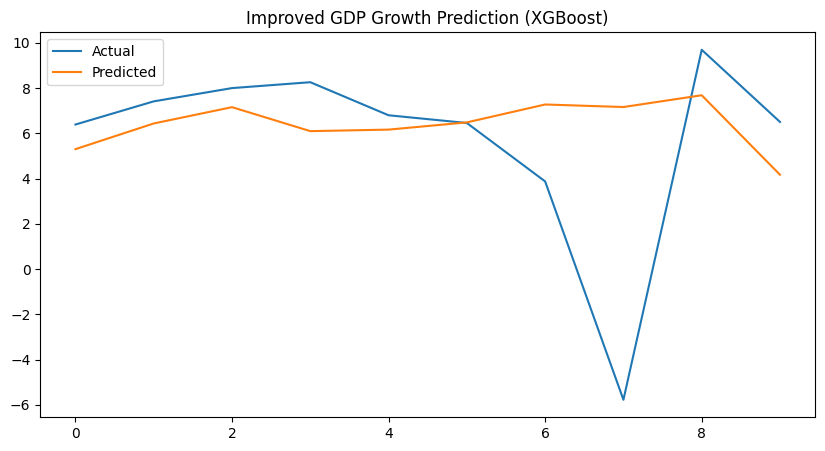

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Improved GDP Growth Prediction (XGBoost)")
plt.show()

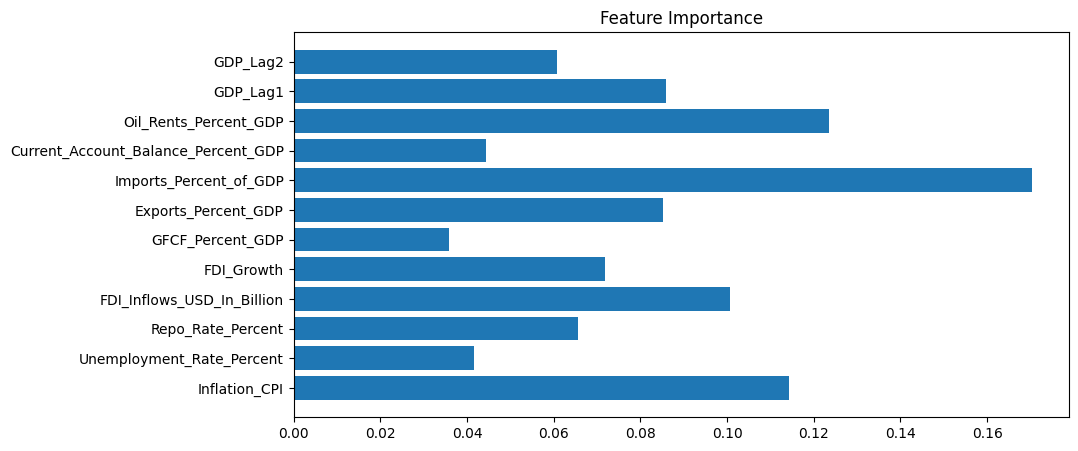

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

# 🔶 STRATEGY SHIFT - More Updations

In [ ]:
features = [
    'GDP_Lag1',
    'GDP_Lag2',
    'Inflation_CPI',
    'Repo_Rate_Percent',
    'Oil_Rents_Percent_GDP'
]

In [ ]:
df['Trend'] = np.arange(len(df))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train) # Corrected: Fit the RandomForestRegressor model with X_train and y_train

RandomForestRegressor(max_depth=4, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.5443228521274452
RMSE: 4.3819912084114465
R2 Score: -0.1390610126185592


# 🔶 Data Mining & Warehousing - PART 04: TIME-SERIES MODELING (ARIMA)

In [ ]:
pip install statsmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
df = pd.read_csv("clean_indian_economy.csv")

# Convert 'Year' to datetime objects and set as index for proper time series handling
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

# Convert problematic column to numeric, coercing errors
df['Oil_Rents_Percent_GDP'] = pd.to_numeric(df['Oil_Rents_Percent_GDP'], errors='coerce')

# Drop rows with NaN values that might have been introduced by coerce or other operations
df.dropna(inplace=True)

# Target
y = df['GDP_Growth_Annual_Percent']

# Train-test split
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# ARIMA model
model = ARIMA(train, order=(2,1,2))   # (p,d,q)
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [ ]:
# Evaluation
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.199601276102928
RMSE: 4.042026459286416


# 🔶 Data Mining & Warehousing - PART 05: ARIMA + Machine Learning (HYBRID MODEL)

In [ ]:
residuals = train - model_fit.fittedvalues

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# Prepare features (same as before but aligned to train)
feature_cols = ['Inflation_CPI', 'Repo_Rate_Percent', 'Oil_Rents_Percent_GDP']

# Extract features from the global df, which should have been cleaned in mpjIIirIC_zK.
X = df[feature_cols].copy()

# Explicitly ensure numeric types and handle any lingering non-numeric issues.
# This step acts as a safeguard even if previous cleaning was applied.
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Drop any rows that now contain NaN values resulting from coercion, if any
X.dropna(inplace=True)

# Ensure residuals index is DatetimeIndex, matching X's index for correct lookup
# This step is crucial if 'residuals' was generated before df's index was set to DatetimeIndex
if not isinstance(residuals.index, pd.DatetimeIndex):
    residuals.index = pd.to_datetime(residuals.index, format='%Y')

# Align residuals (which correspond to the ARIMA training period) with the cleaned X_train data.
# The 'residuals' Series is indexed by 'Year' which was the index of `train`.
# We need X_train to have matching indices with 'residuals'.
# We use the index of `residuals` to select corresponding rows from `X`.
X_train_rf = X.loc[residuals.index]
y_residuals_train = residuals # The residuals Series is already the target for training RF

# For the test set, we need features (X_test_rf) corresponding to the `test` data (actual values).
# The `test` Series is indexed by 'Year'.
X_test_rf = X.loc[test.index]

# Train on residuals
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_residuals_train)

# Predict residuals
predicted_residuals = rf.predict(X_test_rf)

# Correctly align forecast with the test index by using forecast.values
arima_forecast_aligned = pd.Series(forecast.values, index=test.index[:len(forecast)])

# To combine, ensure both arima_forecast_aligned and predicted_residuals are aligned to the same indices (X_test_rf.index)
final_arima_forecast = arima_forecast_aligned.loc[X_test_rf.index]
hybrid_forecast = final_arima_forecast + predicted_residuals

# Now, 'test' (actual values for the test period) needs to be aligned with X_test_rf.index for evaluation.
y_actual_test_aligned = test.loc[X_test_rf.index]

Hybrid Model MAE: 2.3479176682983547
Hybrid Model RMSE: 4.3656637598700865


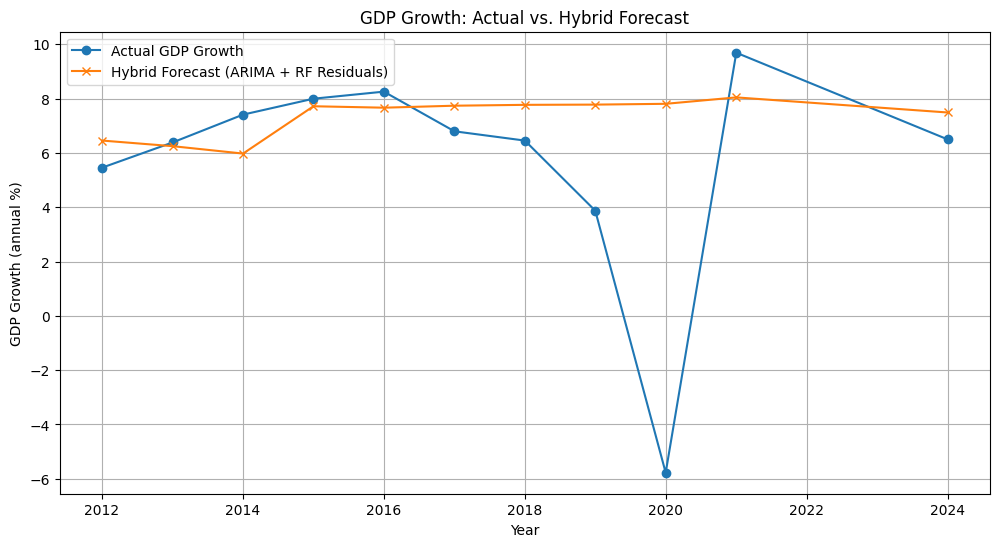

In [ ]:
# The hybrid_forecast was already calculated in the previous cell.
# If you need to re-assign it to a new variable name 'final_pred', you can do so.
final_pred = hybrid_forecast

# Evaluate the hybrid model
mae_hybrid = mean_absolute_error(y_actual_test_aligned, final_pred)
rmse_hybrid = np.sqrt(mean_squared_error(y_actual_test_aligned, final_pred))

print("Hybrid Model MAE:", mae_hybrid)
print("Hybrid Model RMSE:", rmse_hybrid)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(y_actual_test_aligned.index, y_actual_test_aligned, label="Actual GDP Growth", marker='o')
plt.plot(final_pred.index, final_pred, label="Hybrid Forecast (ARIMA + RF Residuals)", marker='x')
plt.title("GDP Growth: Actual vs. Hybrid Forecast")
plt.xlabel("Year")
plt.ylabel("GDP Growth (annual %)")
plt.legend()
plt.grid(True)
plt.show()

# 🔶 Data Mining & Warehousing - PART 06: Tune ARIMA

In [ ]:
order=(2,1,2)

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.4 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

auto_model = pm.auto_arima(train,
                           start_p=0, start_q=0,
                           max_p=5, max_q=5,
                           d=1,
                           seasonal=False,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=231.391, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=218.612, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=229.410, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=212.374, Time=0.28 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=214.197, Time=0.24 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.69 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=210.814, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=216.771, Time=0.03 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=212.682, Time=0.15 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=206.753, Time=0.16 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=205.166, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=204.261, Time=0.13 se

In [ ]:
best_order = auto_model.order
print("Best Order:", best_order)

Best Order: (0, 1, 1)


In [ ]:
model = ARIMA(train, order=best_order)
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("Final MAE:", mae)
print("Final RMSE:", rmse)

Final MAE: 2.1632190127538684
Final RMSE: 3.9834460873834896


In [ ]:
# Best model: ARIMA(1,1,1)

In [ ]:
best_order = auto_model.order
print("Best Order:", best_order)

Best Order: (0, 1, 1)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=best_order)
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [ ]:
forecast = model_fit.forecast(steps=len(test))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("Final MAE:", mae)
print("Final RMSE:", rmse)

Final MAE: 2.1632190127538684
Final RMSE: 3.9834460873834896


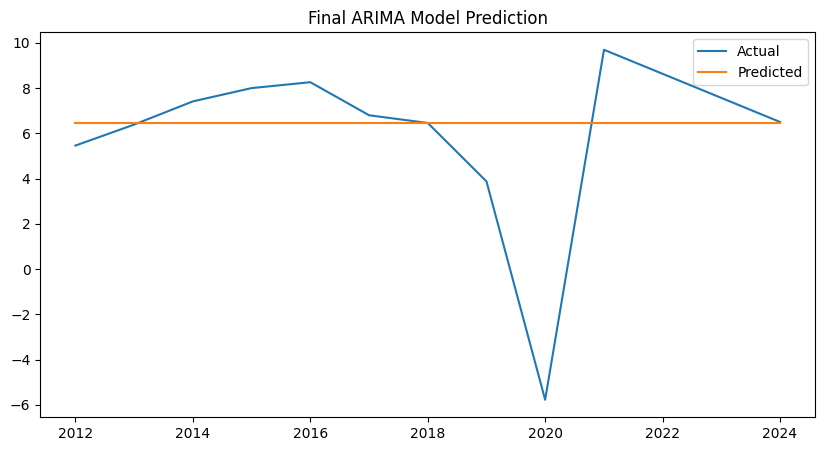

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Predicted")
plt.legend()
plt.title("Final ARIMA Model Prediction")
plt.show()

# 🔶 Data Mining & Warehousing - PART 07: LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(y.values.reshape(-1,1))

In [ ]:
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y_seq = create_sequences(scaled_data)

In [ ]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X.shape[1],1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
pred = model.predict(X_test)

# inverse scaling
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


In [ ]:
mae = mean_absolute_error(y_test_actual, pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, pred))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

LSTM MAE: 2.871851030727197
LSTM RMSE: 4.372522483065239


# ⚡DASHBOARD

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 79.9 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("clean_indian_economy.csv")

# Ensure all columns (except 'Year') are numeric
numeric_cols = df.columns.drop('Year', errors='ignore') # Exclude 'Year' from conversion
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with any NaN values that resulted from the coercion
df.dropna(inplace=True)

st.title("📊 India GDP Analysis Dashboard")

st.subheader("GDP Growth Over Time")
plt.figure(figsize=(10, 6)) # Add a figure for this plot to avoid interference
plt.plot(df['Year'], df['GDP_Growth_Annual_Percent'])
st.pyplot(plt)

st.subheader("Correlation")
st.write(df.corr())

2026-04-08 13:03:45.291 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 13:03:45.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 13:03:45.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 13:03:45.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 13:03:45.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 13:03:45.299 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 13:03:45.324 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 13:03:45.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

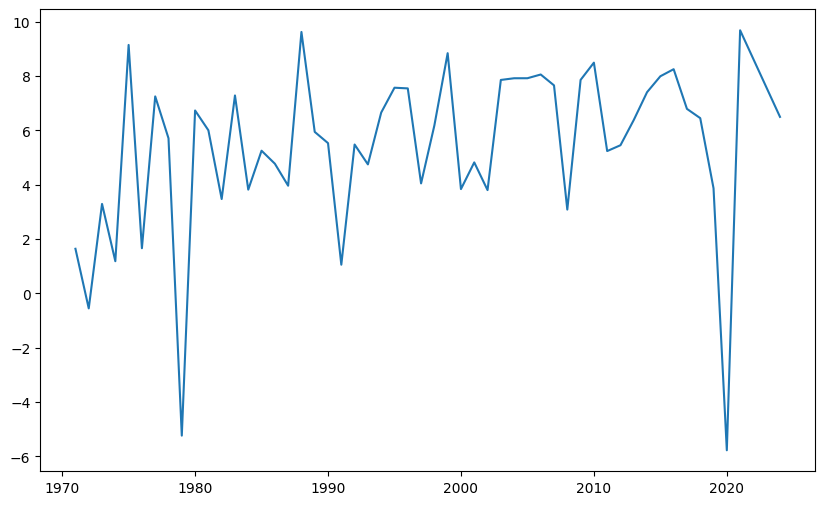

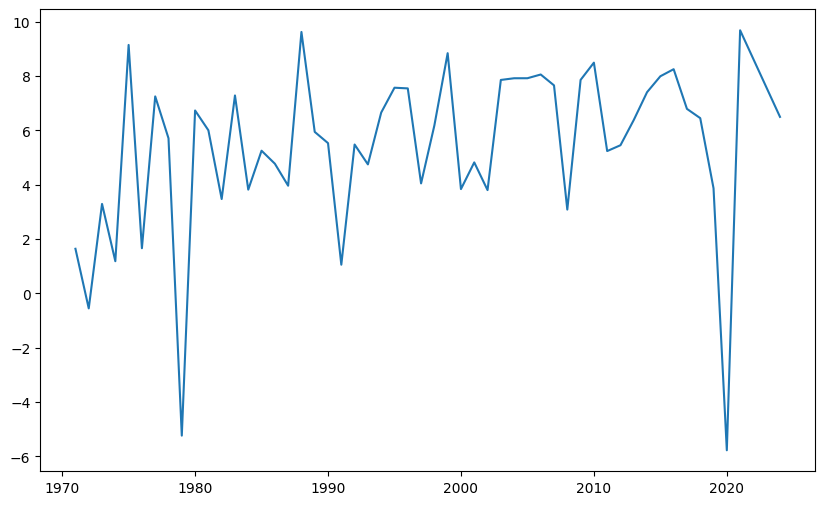

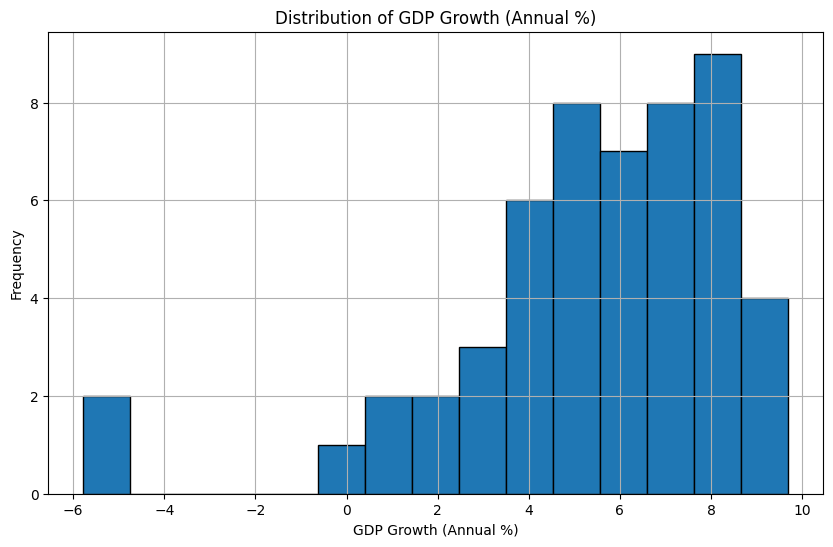

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['GDP_Growth_Annual_Percent'], bins=15, edgecolor='black')
plt.title('Distribution of GDP Growth (Annual %)')
plt.xlabel('GDP Growth (Annual %)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:

# Model	MAE	RMSE
# ARIMA	2.16	3.98
# LSTM	2.87	4.37
# Hybrid (ARIMA + RF)	2.35	4.37


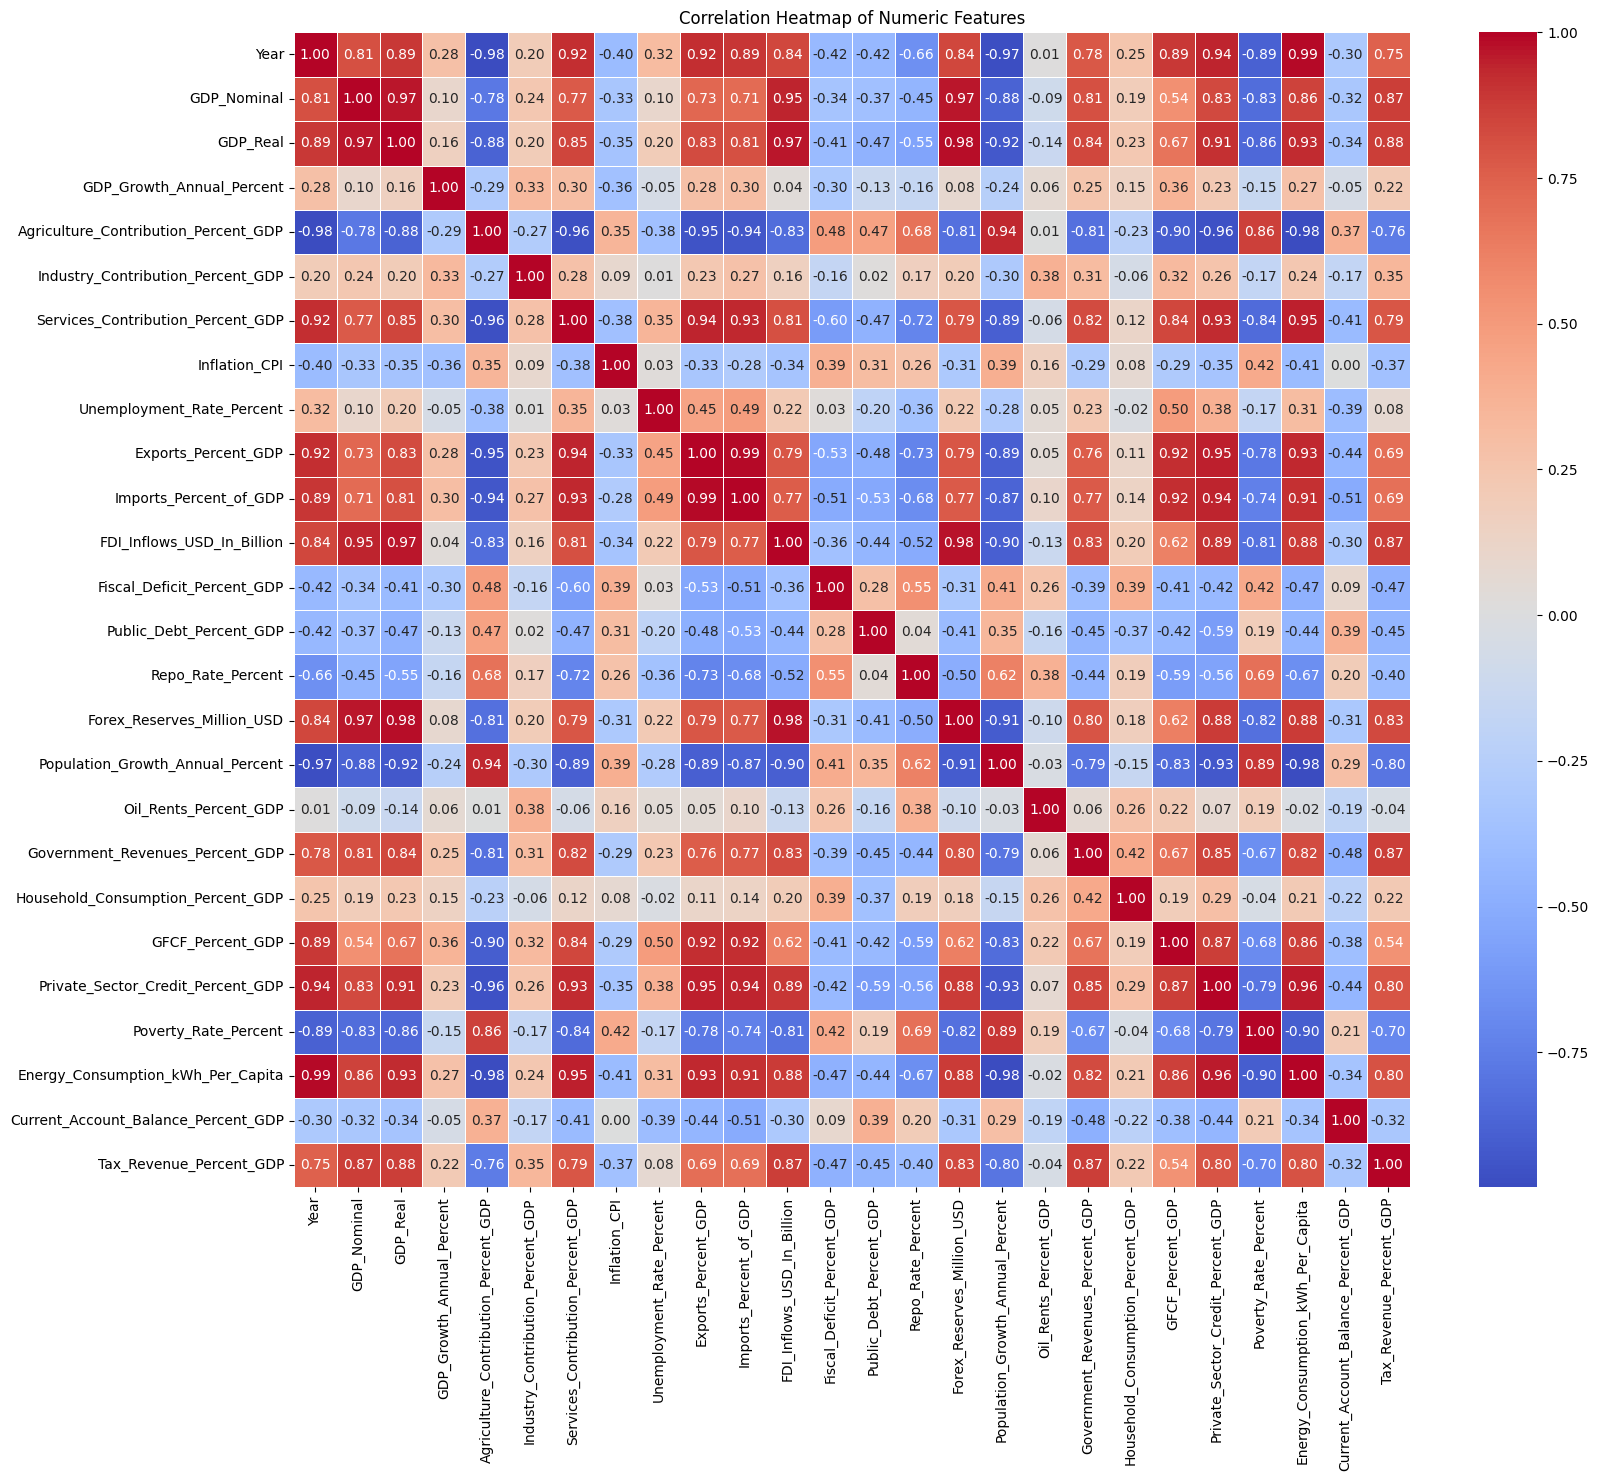

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation heatmap
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Create a heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [ ]:
gdp_real_correlations = corr_matrix['GDP_Real'].sort_values(ascending=False)

# Exclude GDP_Real itself from the list
gdp_real_correlations = gdp_real_correlations.drop('GDP_Real')

print("Features most strongly correlated with GDP_Real:")
print(gdp_real_correlations.head(10))
print("\nFeatures most strongly negatively correlated with GDP_Real:")
print(gdp_real_correlations.tail(5))

Features most strongly correlated with GDP_Real:
Forex_Reserves_Million_USD           0.977994
GDP_Nominal                          0.967538
FDI_Inflows_USD_In_Billion           0.967324
Energy_Consumption_kWh_Per_Capita    0.926694
Private_Sector_Credit_Percent_GDP    0.913998
Year                                 0.890364
Tax_Revenue_Percent_GDP              0.876116
Services_Contribution_Percent_GDP    0.850507
Government_Revenues_Percent_GDP      0.844351
Exports_Percent_GDP                  0.826600
Name: GDP_Real, dtype: float64

Features most strongly negatively correlated with GDP_Real:
Public_Debt_Percent_GDP                -0.470696
Repo_Rate_Percent                      -0.548707
Poverty_Rate_Percent                   -0.856871
Agriculture_Contribution_Percent_GDP   -0.875126
Population_Growth_Annual_Percent       -0.923653
Name: GDP_Real, dtype: float64


# ⚡Forecast Next Year (2025)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Use full data now
model = ARIMA(y, order=(0,1,1))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



In [ ]:
forecast = model_fit.forecast(steps=3)
print(forecast)

52    5.720235
53    5.720235
54    5.720235
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [ ]:
gdp_2025 = forecast.iloc[-1]
print("Predicted GDP Growth for 2025:", gdp_2025)

Predicted GDP Growth for 2025: 5.720234528182423


In [ ]:
forecast_results = model_fit.get_forecast(steps=3)
forecast = forecast_results.predicted_mean
conf_int = forecast_results.conf_int(alpha=0.05)

print(conf_int)

    lower GDP_Growth_Annual_Percent  upper GDP_Growth_Annual_Percent
52                        -0.552954                        11.993423
53                        -0.583687                        12.024156
54                        -0.614272                        12.054741


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [ ]:
avg_gdp = y.mean()

accuracy = (1 - (2.16 / avg_gdp)) * 100
print("Approx Accuracy (%):", accuracy)

Approx Accuracy (%): 59.64361581204951


In [ ]:
avg_gdp = y.mean()

error_percent = (2.16 / avg_gdp) * 100
reliability = 100 - error_percent

print("Model Error (%):", error_percent)
print("Model Reliability (%):", reliability)

Model Error (%): 40.35638418795049
Model Reliability (%): 59.64361581204951


In [ ]:
forecast_results = model_fit.get_forecast(steps=3)
forecast = forecast_results.predicted_mean
conf_int = forecast_results.conf_int(alpha=0.05)

print(conf_int)

    lower GDP_Growth_Annual_Percent  upper GDP_Growth_Annual_Percent
52                        -0.552954                        11.993423
53                        -0.583687                        12.024156
54                        -0.614272                        12.054741


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [ ]:
# Mean GDP
avg_gdp = y.mean()

# Your MAE
mae = 2.1632190127538684

# Accuracy %
accuracy = (1 - (mae / avg_gdp)) * 100

print("Model Accuracy (%):", accuracy)

Model Accuracy (%): 59.5834733512157


# 📊 Model Comparision

In [ ]:
import plotly.express as px
import pandas as pd

models = ['Random Forest', 'XGBoost', 'Hybrid', 'ARIMA Init', 'ARIMA Final', 'LSTM']
mae = [2.54, 2.4, 2.34, 2.25, 2.16, 2.8]

df_mae = pd.DataFrame({'Model': models, 'MAE': mae})

# Sort the DataFrame by MAE for better visualization
df_mae = df_mae.sort_values(by='MAE', ascending=True)

fig = px.bar(
    df_mae,
    x='Model',
    y='MAE',
    title='Model Comparison (MAE)',
    color='MAE', # Color bars based on MAE value
    color_continuous_scale=px.colors.sequential.Viridis,
    template='plotly_dark', # Apply a dark theme
    text='MAE' # Add text labels on the bars
)

fig.update_layout(
    xaxis_title='Model',
    yaxis_title='Mean Absolute Error',
    xaxis_tickangle=-30
)

# Update text position and format
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.show()

### Comprehensive Model Performance Comparison (MAE & RMSE)

In [ ]:
import plotly.express as px
import pandas as pd

# Updated model names and corresponding MAE and RMSE values
models = ['Random Forest', 'XGBoost', 'Hybrid (ARIMA+RF)', 'ARIMA Initial', 'ARIMA Final', 'LSTM']
mae_values = [2.544, 2.641, 2.348, 2.199, 2.163, 2.872]
rmse_values = [4.382, 4.431, 4.366, 4.042, 3.983, 4.372]

# Create a DataFrame for both metrics
df_performance = pd.DataFrame({
    'Model': models,
    'MAE': mae_values,
    'RMSE': rmse_values
})

# Melt the DataFrame to long format for facet plotting
df_melted = df_performance.melt(
    id_vars=['Model'],
    value_vars=['MAE', 'RMSE'],
    var_name='Metric',
    value_name='Value'
)

# Sort by MAE to maintain consistent order across metrics for better comparison
df_melted['Model'] = pd.Categorical(df_melted['Model'], categories=df_performance.sort_values(by='MAE')['Model'].tolist(), ordered=True)

fig = px.bar(
    df_melted,
    x='Model',
    y='Value',
    color='Metric', # Color bars based on whether it's MAE or RMSE
    facet_col='Metric', # Create separate columns for MAE and RMSE
    title='Model Performance Comparison (MAE and RMSE)',
    color_continuous_scale=px.colors.sequential.Viridis,
    template='plotly_dark',
    text='Value' # Add text labels on the bars
)

fig.update_layout(
    xaxis_title='Model',
    yaxis_title='Error Value',
    xaxis_tickangle=-30
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_yaxes(matches=None) # Allow independent y-axis scales for each facet

fig.show()

In [ ]:
import pandas as pd

df = pd.read_csv("")

print("Number of Records:", df.shape[0])
print("Number of Features:", df.shape[1])
print("Columns:\n", df.columns.tolist())

print("Year Range:", df['Year'].min(), "to", df['Year'].max())

Number of Records: 54
Number of Features: 26
Columns:
 ['Year', 'GDP_Nominal', 'GDP_Real', 'GDP_Growth_Annual_Percent', 'Agriculture_Contribution_Percent_GDP', 'Industry_Contribution_Percent_GDP', 'Services_Contribution_Percent_GDP', 'Inflation_CPI', 'Unemployment_Rate_Percent', 'Exports_Percent_GDP', 'Imports_Percent_of_GDP', 'FDI_Inflows_USD_In_Billion', 'Fiscal_Deficit_Percent_GDP', 'Public_Debt_Percent_GDP', 'Repo_Rate_Percent', 'Forex_Reserves_Million_USD', 'Population_Growth_Annual_Percent', 'Oil_Rents_Percent_GDP', 'Government_Revenues_Percent_GDP', 'Household_Consumption_Percent_GDP', 'GFCF_Percent_GDP', 'Private_Sector_Credit_Percent_GDP', 'Poverty_Rate_Percent', 'Energy_Consumption_kWh_Per_Capita', 'Current_Account_Balance_Percent_GDP', 'Tax_Revenue_Percent_GDP']
Year Range: 1971 to 2024
